In [59]:
import pandas as pd
import os

In [60]:
print(os.path.exists(r"C:\Users\User\Desktop\Recurrent_Neural_Network_Project_Predicting_Response_Status\source\rureviews-master\women-clothing-accessories.3-class.balanced.csv"))

True


In [61]:
df = pd.read_csv("source/rureviews-master/women-clothing-accessories.3-class.balanced.csv", sep="\t")

In [62]:
counts = df['sentiment'].value_counts()
print(counts)

sentiment
negative    30000
neautral    30000
positive    30000
Name: count, dtype: int64


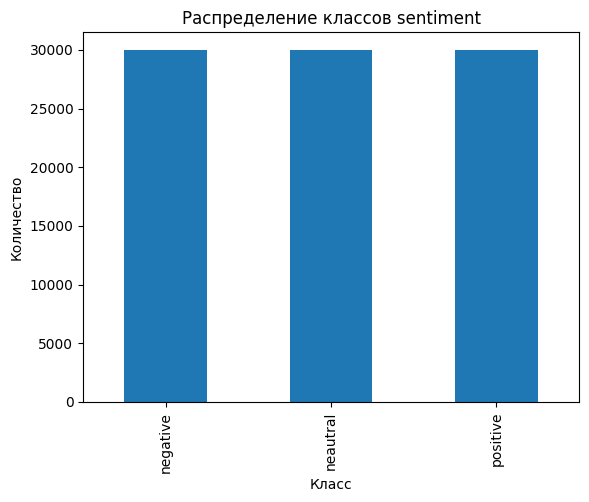

In [63]:
import matplotlib.pyplot as plt

counts.plot(kind='bar')

plt.title('Распределение классов sentiment')
plt.xlabel('Класс')
plt.ylabel('Количество')

plt.show()

In [64]:
print(df.head(30))

                                               review sentiment
0   качество плохое пошив ужасный (горловина напер...  negative
1   Товар отдали другому человеку, я не получила п...  negative
2   Ужасная синтетика! Тонкая, ничего общего с пре...  negative
3   товар не пришел, продавец продлил защиту без м...  negative
4       Кофточка голая синтетика, носить не возможно.  negative
5                               Очень глубокие проймы  negative
6   Я недовольна заказом.Я вот одного не понимаю п...  negative
7   заказала размер s на от 64,об 94,начнем с того...  negative
8   Заказ я сделала в июле. С тех пор посылка отсл...  negative
9                            Ужасное качество товара!  negative
10  короткая кофта нитки торчат,не суразно выгляди...  negative
11         ткань приятная. вот только пятно на спине.  negative
12  рубашка очень маломерит .. заказывала хл пришл...  negative
13  кофта пришла с браком, вот такая дыра на горло...  negative
14  товар застрял во Внуково. видимо кар

In [65]:
print(df[(df['sentiment'] =='positive')])

                                                  review sentiment
60000               Все совпадает! К покупке рекомендую!  positive
60001                          по размеру) качественные)  positive
60002  Прекрасная, качественая рубашка! Искала просту...  positive
60003  Пришло через 2 месяца. Очень долго, но пуловер...  positive
60004  Заказ дошел быстро. Соответствует описанию. Кр...  positive
...                                                  ...       ...
89995  сделано достаточно хорошо. на ткани сделан рис...  positive
89996  Накидка шикарная. Спасибо большое провдо линяе...  positive
89997  спасибо большое ) продовца рекомендую.. заказа...  positive
89998  Очень довольна заказом! Меньше месяца в РБ.  К...  positive
89999  хорошая куртка. постороннего запаха нет. швы р...  positive

[30000 rows x 2 columns]


In [66]:
df.count()

review       90000
sentiment    90000
dtype: int64

In [67]:
df_negative = df[(df['sentiment'] != 'positive') & (df['sentiment'] != 'negative')]
print(df_negative.head(30))

                                                  review sentiment
30000  Пришли с пятном. До МО дошёл товаров за 12 дне...  neautral
30001  посылка шла больше двух месяцев, 72 дня, нам у...  neautral
30002  Заказ пришел вовремя. Качество, конечно, так с...  neautral
30003                                думала будет толще.  neautral
30004  Ткань синтетика голая, прям  не приятная на ощ...  neautral
30005  Пришёл костюм менее чем за месяц, качество рас...  neautral
30006  пришли довольно быстро, оказались малы да и тк...  neautral
30007  Пижама пришла с браком, разводы от краски, тем...  neautral
30008      материал хороший.Но кофта для полных людей...  neautral
30009  товар не очень соответствует описанию. Кофта п...  neautral
30010                                Нуу, так себе вещь   neautral
30011                            Платье не понравилось.   neautral
30012  все бы ничего,но малейшея зацепка и начинают п...  neautral
30013           xl явно не xl, даже не налезла эта майка  neau

In [68]:
# Добавляем новый столбец с количеством слов
df['review_length'] = df['review'].apply(lambda x: len(str(x).split()))

# Смотрим первые 10 отзывов и их длину
print(df[['review', 'review_length']].head(10))

                                              review  review_length
0  качество плохое пошив ужасный (горловина напер...             24
1  Товар отдали другому человеку, я не получила п...             12
2  Ужасная синтетика! Тонкая, ничего общего с пре...             30
3  товар не пришел, продавец продлил защиту без м...             13
4      Кофточка голая синтетика, носить не возможно.              6
5                              Очень глубокие проймы              3
6  Я недовольна заказом.Я вот одного не понимаю п...             22
7  заказала размер s на от 64,об 94,начнем с того...             51
8  Заказ я сделала в июле. С тех пор посылка отсл...            118
9                           Ужасное качество товара!              3


In [69]:
print("Минимальная длина отзыва:", df['review_length'].min())
print("Максимальная длина отзыва:", df['review_length'].max())
print("Средняя длина отзыва:", df['review_length'].mean())

Минимальная длина отзыва: 0
Максимальная длина отзыва: 193
Средняя длина отзыва: 20.011144444444444


In [70]:
print(df['review_length'].quantile(0.5))  # медиана
print(df['review_length'].quantile(0.75))
print(df['review_length'].quantile(0.9))
print(df['review_length'].quantile(0.95))

14.0
25.0
43.0
58.0


In [71]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

tokenizer = Tokenizer(num_words=3000, oov_token="<OOV>")
tokenizer.fit_on_texts(df['review'])

sequences = tokenizer.texts_to_sequences(df['review'])

In [72]:
print(tokenizer.word_index)

{'<OOV>': 1, 'не': 2, 'на': 3, 'и': 4, 'в': 5, 'очень': 6, 'но': 7, 'размер': 8, 'что': 9, 'как': 10, 'с': 11, 'товар': 12, 'качество': 13, 'продавец': 14, 'деньги': 15, 'за': 16, 'по': 17, 'я': 18, 'а': 19, 'так': 20, 'все': 21, 'это': 22, 'доставка': 23, 'то': 24, 'заказ': 25, 'ткань': 26, 'спор': 27, 'мне': 28, 'спасибо': 29, 'к': 30, 'вернули': 31, 'платье': 32, 'заказала': 33, 'соответствует': 34, 'фото': 35, 'быстро': 36, 'цвет': 37, 'до': 38, 'у': 39, 'хорошо': 40, 'рост': 41, 'пришел': 42, 'только': 43, 'пришёл': 44, 'продавца': 45, 'больше': 46, 'пришла': 47, 'нет': 48, '2': 49, 'рекомендую': 50, 'м': 51, 'заказывала': 52, 'для': 53, 'даже': 54, 'рукава': 55, 'нитки': 56, 'месяца': 57, 'синтетика': 58, 'бы': 59, 'раз': 60, 's': 61, 'довольна': 62, 'продавцу': 63, 'было': 64, 'пришло': 65, 'получила': 66, 'хорошее': 67, 'l': 68, '3': 69, 'просто': 70, 'быстрая': 71, 'материал': 72, 'из': 73, 'торчат': 74, 'носить': 75, 'недели': 76, '\r': 77, 'после': 78, 'он': 79, 'размеру': 8

In [73]:
print(df['sentiment'].unique())

['negative' 'neautral' 'positive']


In [74]:
label_map = {
    "positive": 0,
    "negative": 1,
    "neutral": 2,
    "neautral": 2   # ← добавили исправление
}

df['sentiment'] = df['sentiment'].map(label_map).astype('Int32')

In [75]:
df.head()

,review,sentiment,review_length
0,качество плохое пошив ужасный (горловина напер...,1,24
1,"Товар отдали другому человеку, я не получила п...",1,12
2,"Ужасная синтетика! Тонкая, ничего общего с пре...",1,30
3,"товар не пришел, продавец продлил защиту без м...",1,13
4,"Кофточка голая синтетика, носить не возможно.",1,6


In [76]:
df['sequences'] = tokenizer.texts_to_sequences(df['review'])

In [77]:
print(df[['review', 'sequences']].head())

                                              review  \
0  качество плохое пошив ужасный (горловина напер...   
1  Товар отдали другому человеку, я не получила п...   
2  Ужасная синтетика! Тонкая, ничего общего с пре...   
3  товар не пришел, продавец продлил защиту без м...   
4      Кофточка голая синтетика, носить не возможно.   

                                           sequences  
0  [13, 259, 365, 316, 822, 1, 35, 2, 34, 26, 435...  
1  [12, 1, 1125, 1, 18, 2, 66, 301, 1470, 344, 15...  
2  [435, 58, 125, 130, 2375, 11, 1, 2233, 2, 1562...  
3  [12, 2, 42, 14, 1152, 543, 112, 899, 1, 85, 45...  
4                        [322, 1490, 58, 75, 2, 467]  


In [78]:
df.head()

,review,sentiment,review_length,sequences
0,качество плохое пошив ужасный (горловина напер...,1,24,"[13, 259, 365, 316, 822, 1, 35, 2, 34, 26, 435..."
1,"Товар отдали другому человеку, я не получила п...",1,12,"[12, 1, 1125, 1, 18, 2, 66, 301, 1470, 344, 15..."
2,"Ужасная синтетика! Тонкая, ничего общего с пре...",1,30,"[435, 58, 125, 130, 2375, 11, 1, 2233, 2, 1562..."
3,"товар не пришел, продавец продлил защиту без м...",1,13,"[12, 2, 42, 14, 1152, 543, 112, 899, 1, 85, 45..."
4,"Кофточка голая синтетика, носить не возможно.",1,6,"[322, 1490, 58, 75, 2, 467]"


In [79]:
df = df.drop(["review", "review_length"],axis=1)
df.head()

,sentiment,sequences
0,1,"[13, 259, 365, 316, 822, 1, 35, 2, 34, 26, 435..."
1,1,"[12, 1, 1125, 1, 18, 2, 66, 301, 1470, 344, 15..."
2,1,"[435, 58, 125, 130, 2375, 11, 1, 2233, 2, 1562..."
3,1,"[12, 2, 42, 14, 1152, 543, 112, 899, 1, 85, 45..."
4,1,"[322, 1490, 58, 75, 2, 467]"


In [80]:
print(df.isna().sum())

sentiment    0
sequences    0
dtype: int64


In [81]:
counts = df['sentiment'].value_counts()
print(counts)

sentiment
1    30000
2    30000
0    30000
Name: count, dtype: Int64


In [82]:
import matplotlib.pyplot as plt

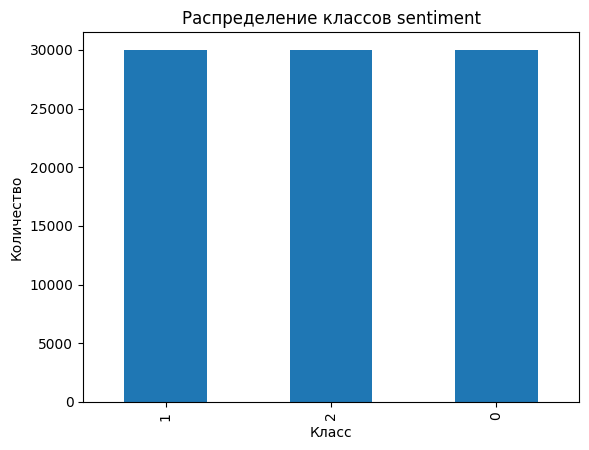

In [83]:
counts.plot(kind='bar')

plt.title('Распределение классов sentiment')
plt.xlabel('Класс')
plt.ylabel('Количество')

plt.show()

In [84]:
# Для обучения модели используется словарь только из 3000 слов но при этом
#  словаре 55993, это делается чтобы избежать переобучения, будут использоваться 3000 наиболее часто встречающихся строк, все значения котоыре не попали под эот сиписок зкменяются на <OOV>, это не испортит уровень обучения модели, так как RNN нейронные сети основаны на обучении на частотных патернах
num_features = len(tokenizer.word_index)
print(num_features)

55993


In [85]:
# Выполняем сокращение и увеличение непрерывных рядов, это необходимо для RNN, добавляет 0 до длины 60. Задаем также переменные для обучения модели
X = pad_sequences(
    df['sequences'],
    maxlen=60,
    padding='post',   # дополняем справа
    truncating='post' # обрезаем справа
)

print(X.shape)

(90000, 60)


In [86]:
# Задаем переменную для тренирующей выборки и обучения модели
y = df['sentiment'].values

print(y.shape)
print(y[:10])

(90000,)
<IntegerArray>
[1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
Length: 10, dtype: Int32


In [87]:
import numpy as np

# Из-за того что мы уже проиндексировали и преобразовали предложения в последовательность целых чисел нам необходимо преобразовать массивы в массивы чисел с плавающей точкой чтобы включить пропуски в последовательности: NaN нельзя хранить в int-массивах
X_missing = X.astype('float')

# создаём маску пропусков (15% элементов)
# условие ЛР: >10% NaN
mask = np.random.rand(*X_missing.shape) < 0.15

# заменяем значения на NaN
X_missing[mask] = np.nan

print("Доля пропусков:", np.isnan(X_missing).mean())

Доля пропусков: 0.1498362962962963


In [88]:
# Forward-fill (простое восстановление)
# заполняем NaN предыдущим значением в последовательности
X_ffill = pd.DataFrame(X_missing).ffill(axis=1).values

# если NaN остались в начале → заменяем на 0
X_ffill = np.nan_to_num(X_ffill, nan=0)

In [89]:
# Линейная интерполяция
# восстанавливаем значения по линейному тренду
X_interp = pd.DataFrame(X_missing).interpolate(axis=1).values

# убираем оставшиеся NaN
X_interp = np.nan_to_num(X_interp, nan=0)

In [90]:
# Аугментация данных
# Слой шума (Gaussian Noise)
def add_noise(X, noise_level=0.05):

    # Аугментация данных:
    # добавление гауссовского шума для повышения устойчивости модели

    noise = np.random.normal(0, noise_level, X.shape)
    return X + noise

X_noisy = add_noise(X_ffill)

In [91]:
# Dropout-аугментация (для последовательностей)
def sequence_dropout(X, drop_prob=0.05):
# Случайное зануление элементов последовательности имитация потери информации
    X_aug = X.copy()
    mask = np.random.rand(*X.shape) < drop_prob
    X_aug[mask] = 0
    return X_aug

X_augmented = sequence_dropout(X_ffill)